# L3 Cavity with Conical Holes — Fabrication Taper Study
During dry etching (RIE/ICP), hole sidewalls can develop a slight taper,
producing cone-shaped holes — wider at the top (etch entry) and narrower at
the bottom. This notebook models the effect on the L3 cavity Q-factor using
a staircase approximation (multiple thin slab sub-layers with varying radii).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import legume
from legume import Circle

## Band structure of the perfect PhC (unit cell)

Bandgap: 0.2489 – 0.3274,  centre f_target = 0.2882


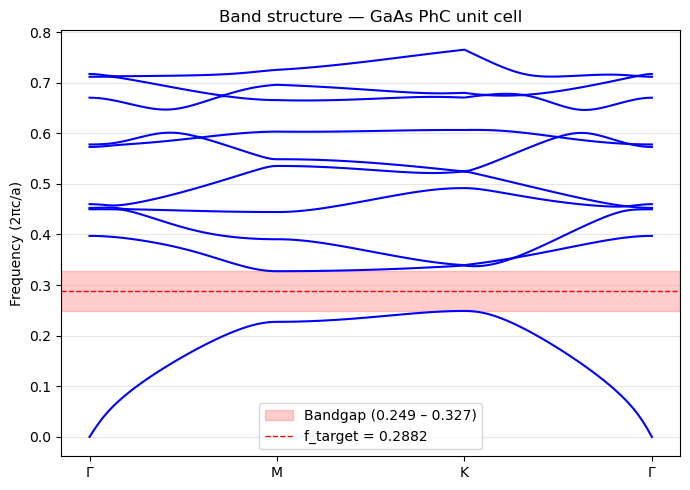

In [3]:
# ── Physical parameters ─────────────────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a
dslab = 170 / a_nm      # slab thickness in units of a
n_slab = 3.46           # refractive index (GaAs)

lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f'Bandgap: {f_lb:.4f} \u2013 {f_ub:.4f},  centre f_target = {f_target:.4f}')

# Plot band structure
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(freqs_b.shape[1]):
    ax.plot(freqs_b[:, i], 'b-', lw=1.5)
ax.axhspan(f_lb, f_ub, alpha=0.2, color='red',
           label=f'Bandgap ({f_lb:.3f} \u2013 {f_ub:.3f})')
ax.axhline(f_target, color='red', ls='--', lw=1,
           label=f'f_target = {f_target:.4f}')
ax.set_xticks([0, 40, 80, 120])
ax.set_xticklabels(['\u0393', 'M', 'K', '\u0393'])
ax.set_ylabel('Frequency (2\u03c0c/a)')
ax.set_title('Band structure \u2014 GaAs PhC unit cell')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ── Supercell parameters ───────────────────────────────────────────────────
Nx, Ny = 16, 10

# Initialize supercell lattice
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Build hole positions in one quadrant (L3: skip ix=0,1 at iy=0)
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

nc = len(xp)

# Optimized end-hole shift (from autograd optimization notebook)
dx_opt = 0.17964
dx = np.zeros(nc)
dy = np.zeros(nc)
dx[0] = dx_opt  # ic=0 -> end holes at (+-2, 0)

print(f'nc = {nc} holes per quadrant')
print(f'Optimized end-hole shift: dx[0] = {dx_opt}a = {dx_opt * a_nm:.1f} nm')

nc = 52 holes per quadrant
Optimized end-hole shift: dx[0] = 0.17964a = 44.9 nm


## Conical cavity builder

In [5]:
def cavity_conical(taper_angle_deg, n_slices=10):
    """Build an L3 cavity with conical (tapered) holes.

    Uses a staircase approximation: the slab is divided into n_slices
    sub-layers, each with a linearly varying hole radius.

    The taper is one-sided (realistic RIE profile):
      - r_top = ra (nominal radius, at etch entry / top surface)
      - r_bottom = ra - dslab * tan(taper_angle)

    Parameters
    ----------
    taper_angle_deg : float
        Sidewall taper angle in degrees, measured from vertical.
        0 = perfectly vertical walls (no taper).
    n_slices : int
        Number of sub-layers for the staircase approximation.
    """
    taper_rad = np.radians(taper_angle_deg)
    r_top = ra
    r_bottom = ra - dslab * np.tan(taper_rad)

    if r_bottom <= 0:
        raise ValueError(
            f'Taper too large: r_bottom = {r_bottom*a_nm:.1f} nm <= 0 '
            f'(angle = {taper_angle_deg} deg)')

    d_slice = dslab / n_slices
    phc = legume.PhotCryst(lattice)

    # Add sub-layers from top to bottom
    for k in range(n_slices):
        z_center = (k + 0.5) * d_slice  # distance from top surface
        frac = z_center / dslab
        r_k = r_top * (1 - frac) + r_bottom * frac  # linear interpolation

        phc.add_layer(d=d_slice, eps_b=n_slab**2)

        for ic in range(nc):
            yc = yp[ic]
            xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0

            positions = [(xc, yc)]
            if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
                positions.append((-xc, -yc))
            if nx-1.6 > xp[ic] > 0:
                positions.append((-xc, yc))
            if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
                positions.append((xc, -yc))

            for (px, py) in positions:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_k), layer=k)

    return phc


# Print radius variation for reference
print('Taper angle -> bottom radius:')
for angle in [0, 1, 2, 3, 4, 5]:
    r_bot = ra - dslab * np.tan(np.radians(angle))
    print(f'  {angle} deg:  r_top = {ra*a_nm:.1f} nm,  '
          f'r_bottom = {r_bot*a_nm:.1f} nm,  '
          f'Delta_r = {dslab*np.tan(np.radians(angle))*a_nm:.1f} nm')

Taper angle -> bottom radius:
  0 deg:  r_top = 75.0 nm,  r_bottom = 75.0 nm,  Delta_r = 0.0 nm
  1 deg:  r_top = 75.0 nm,  r_bottom = 72.0 nm,  Delta_r = 3.0 nm
  2 deg:  r_top = 75.0 nm,  r_bottom = 69.1 nm,  Delta_r = 5.9 nm
  3 deg:  r_top = 75.0 nm,  r_bottom = 66.1 nm,  Delta_r = 8.9 nm
  4 deg:  r_top = 75.0 nm,  r_bottom = 63.1 nm,  Delta_r = 11.9 nm
  5 deg:  r_top = 75.0 nm,  r_bottom = 60.1 nm,  Delta_r = 14.9 nm


## Visualize structure

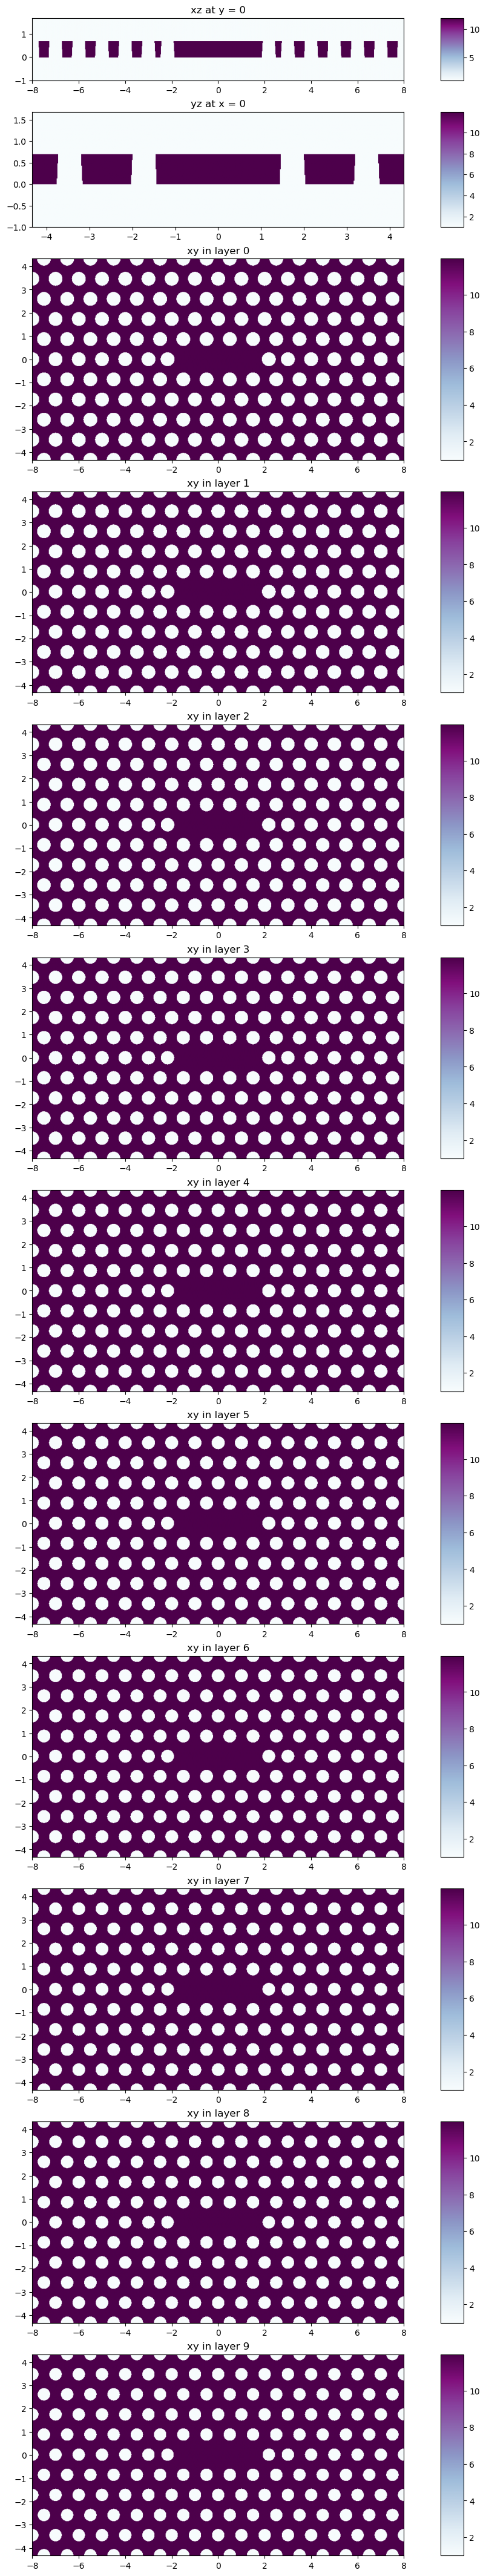

In [6]:
# Visualize the conical cavity (3 deg taper)
phc_viz = cavity_conical(3.0, n_slices=10)
legume.viz.structure(phc_viz, xz=True, yz=True, figsize=8,
                     Nx=800, Ny=500, Nz=100, cmap='BuPu')

## Convergence study: Q vs number of slices
Determine how many sub-layers are needed for converged results.

Convergence study (taper = 3 deg):
  n_slices = 20,  Q =     4624.0,  f = 0.26905


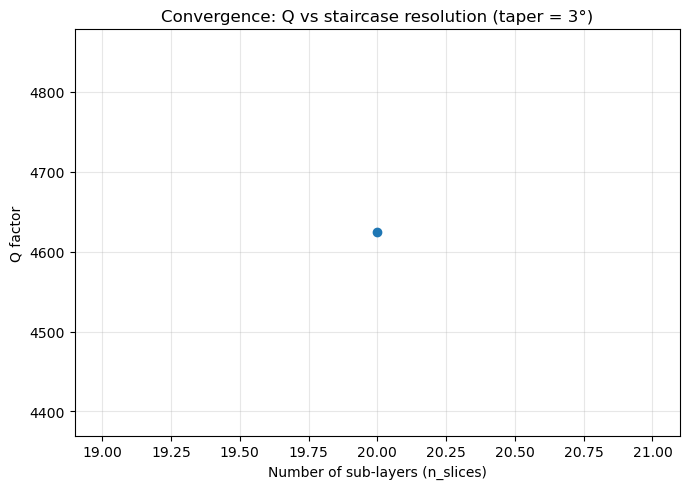

In [12]:
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx', 'compute_im': False}

# Convergence test at 3 deg taper
n_slices_list = [1, 2, 4, 6, 8, 10, 14, 18]
n_slices_list = [20]  # fewer points for quick testing --- IGNORE ---`
Qs_conv = []
freqs_conv = []

print('Convergence study (taper = 3 deg):')
for ns in n_slices_list:
    phc_c = cavity_conical(1.0, n_slices=ns)
    gme_c = legume.GuidedModeExp(phc_c, gmax=gmax, truncate_g=truncate_g)
    gme_c.run(kpoints=np.array([[0], [0]]), **options)

    # Find L3 mode: candidates near f_target, pick highest Q
    all_freqs = gme_c.freqs[0, :]
    candidates = np.where(np.abs(all_freqs - f_target) < 0.02)[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_c.compute_rad(0, [c])
        Qc = gme_c.freqs[0, c] / (2 * fim[0])
        if Qc > best_Q:
            best_Q, mind = Qc, c

    Qs_conv.append(best_Q)
    freqs_conv.append(gme_c.freqs[0, mind])
    print(f'  n_slices = {ns:2d},  Q = {best_Q:10.1f},  f = {gme_c.freqs[0, mind]:.5f}')

# Plot convergence
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_slices_list, Qs_conv, 'o-', lw=1.5, ms=6)
ax.set_xlabel('Number of sub-layers (n_slices)')
ax.set_ylabel('Q factor')
ax.set_title('Convergence: Q vs staircase resolution (taper = 3\u00b0)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Baseline: no taper (0 deg)

Modes near bandgap centre (bandgap: 0.2489 – 0.3274):
  Mode 0: f = 0.25754,  Q = 198852.0 <-- IN BANDGAP
  Mode 1: f = 0.27028,  Q = 5372.3 <-- IN BANDGAP
  Mode 2: f = 0.27955,  Q = 726.8 <-- IN BANDGAP
  Mode 3: f = 0.28162,  Q = 253.8 <-- IN BANDGAP
  Mode 4: f = 0.28371,  Q = 274.2 <-- IN BANDGAP
  Mode 5: f = 0.29405,  Q = 1853.0 <-- IN BANDGAP
  Mode 6: f = 0.31682,  Q = 1324.3 <-- IN BANDGAP
  Mode 7: f = 0.31761,  Q = 4816.1 <-- IN BANDGAP
  Mode 8: f = 0.31990,  Q = 8921.6 <-- IN BANDGAP
  Mode 9: f = 0.32488,  Q = 2361.7 <-- IN BANDGAP

Baseline (0 deg taper): mode_idx = 0, f = 0.25754, Q = 198852.0


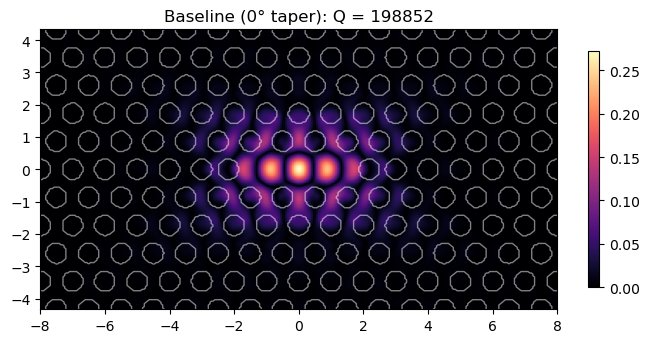

In [8]:
# Use the converged n_slices (even for 0 deg, to keep the layer count consistent)
n_slices = 10  # adjust based on convergence study above

phc_base = cavity_conical(0.0, n_slices=n_slices)
gme_base = legume.GuidedModeExp(phc_base, gmax=gmax, truncate_g=truncate_g)
gme_base.run(kpoints=np.array([[0], [0]]), **options)

# Identify L3 cavity mode
print(f'Modes near bandgap centre (bandgap: {f_lb:.4f} \u2013 {f_ub:.4f}):')
mode_idx = None
for i in range(gme_base.freqs.shape[1]):
    (freq_im_i, _, _) = gme_base.compute_rad(0, [i])
    Qi = gme_base.freqs[0, i] / (2 * freq_im_i[0])
    in_gap = f_lb < gme_base.freqs[0, i] < f_ub
    tag = ' <-- IN BANDGAP' if in_gap else ''
    print(f'  Mode {i}: f = {gme_base.freqs[0, i]:.5f},  Q = {Qi:.1f}{tag}')
    if in_gap and mode_idx is None:
        mode_idx = i

if mode_idx is None:
    raise RuntimeError('No mode found inside the bandgap')

(freq_im, _, _) = gme_base.compute_rad(0, [mode_idx])
Q_base = gme_base.freqs[0, mode_idx] / (2 * freq_im[0])
f_base = gme_base.freqs[0, mode_idx]
print(f'\nBaseline (0 deg taper): mode_idx = {mode_idx}, f = {f_base:.5f}, Q = {Q_base:.1f}')

ax = legume.viz.field(gme_base, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f'Baseline (0\u00b0 taper): Q = {Q_base:.0f}')
plt.show()

## Single conical run

Taper = 3.0 deg:  f = 0.26681,  Q = 2155.1
Change from baseline:  Delta_f = 0.00927,  Delta_Q = -196696.9


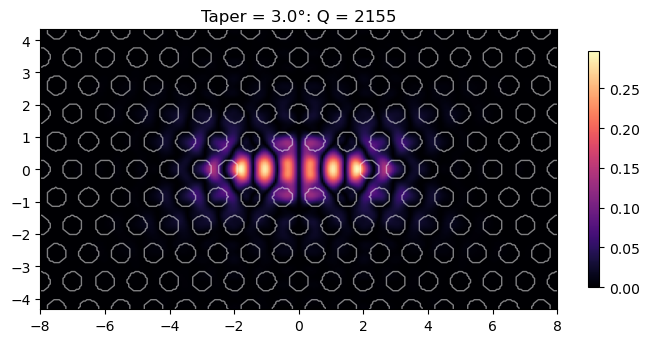

In [9]:
# Single run at 3 deg taper
taper_test = 3.0  # degrees

phc_cone = cavity_conical(taper_test, n_slices=n_slices)
gme_cone = legume.GuidedModeExp(phc_cone, gmax=gmax, truncate_g=truncate_g)
gme_cone.run(kpoints=np.array([[0], [0]]), **options)

# Find L3 mode by highest Q near baseline frequency
all_freqs = gme_cone.freqs[0, :]
candidates = np.where(np.abs(all_freqs - f_base) < 0.02)[0]
best_Q, mind = -1, 0
for c in candidates:
    (fim, _, _) = gme_cone.compute_rad(0, [c])
    Qc = gme_cone.freqs[0, c] / (2 * fim[0])
    if Qc > best_Q:
        best_Q, mind = Qc, c

Q_cone = best_Q
f_cone = gme_cone.freqs[0, mind]

print(f'Taper = {taper_test} deg:  f = {f_cone:.5f},  Q = {Q_cone:.1f}')
print(f'Change from baseline:  Delta_f = {f_cone - f_base:.5f},  Delta_Q = {Q_cone - Q_base:.1f}')

ax = legume.viz.field(gme_cone, 'e', 0, mind, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f'Taper = {taper_test}\u00b0: Q = {Q_cone:.0f}')
plt.show()

## Q factor vs taper angle

In [10]:
# Sweep taper angle from 0 to 5 degrees
taper_angles = np.linspace(0, 5, 21)  # 0.25 deg steps
Qs_sweep = []
freqs_sweep = []

options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'gradients': 'approx', 'compute_im': False}

f_prev = f_base  # seed tracking

print('Sweeping taper angle:')
for angle in taper_angles:
    phc_s = cavity_conical(angle, n_slices=n_slices)
    gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
    gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep)

    # Q-based mode selection: candidates near f_prev, pick highest Q
    all_freqs = gme_s.freqs[0, :]
    candidates = np.where(np.abs(all_freqs - f_prev) < 0.02)[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_s.compute_rad(0, [c])
        Qc = gme_s.freqs[0, c] / (2 * fim[0])
        if Qc > best_Q:
            best_Q, mind = Qc, c

    f_s = gme_s.freqs[0, mind]
    f_prev = f_s

    Qs_sweep.append(best_Q)
    freqs_sweep.append(f_s)

    r_bot = ra - dslab * np.tan(np.radians(angle))
    print(f'  angle = {angle:5.2f} deg,  r_bot = {r_bot*a_nm:5.1f} nm,  '
          f'Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

print('Sweep complete.')

Sweeping taper angle:
  angle =  0.00 deg,  r_bot =  75.0 nm,  Q =   198852.0,  f = 0.25754  (mode 8)
  angle =  0.25 deg,  r_bot =  74.3 nm,  Q =   197412.2,  f = 0.25723  (mode 8)


KeyboardInterrupt: 

In [ ]:
# ── Plot sweep results ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Q vs taper angle
ax1.plot(taper_angles, Qs_sweep, 'o-', lw=1.5, ms=5)
ax1.set_xlabel('Sidewall taper angle (deg)')
ax1.set_ylabel('Q factor')
ax1.set_title('L3 Cavity Q vs Hole Taper Angle')
ax1.grid(True, alpha=0.3)

# Wavelength vs taper angle
lambdas_nm = [a_nm / f for f in freqs_sweep]
ax2.plot(taper_angles, lambdas_nm, 'o-', lw=1.5, ms=5, color='tab:green')
ax2.set_xlabel('Sidewall taper angle (deg)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Cavity Wavelength vs Taper Angle (a = {a_nm} nm)')
ax2.grid(True, alpha=0.3)

plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print('=' * 75)
print(f'{"angle (deg)":>12}  {"r_bot (nm)":>10}  {"Q":>10}  {"f (norm)":>10}  {"lambda (nm)":>12}')
print('-' * 75)
for ang, q, f, lam in zip(taper_angles, Qs_sweep, freqs_sweep, lambdas_nm):
    r_bot = ra - dslab * np.tan(np.radians(ang))
    print(f'{ang:>12.2f}  {r_bot*a_nm:>10.1f}  {q:>10.1f}  {f:>10.5f}  {lam:>12.1f}')
print('=' * 75)